<a href="https://colab.research.google.com/github/Ajwad07/ML_projects_/blob/main/Lab_task_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center> <h1> <u> <font color='red'> Training on AI and ML with Python (Intermediate) </font> </u> </h1> </center>

#Session-10: Simple Linear Regression



###Objective:
 1. To implement Linear Regression from scratch.
 2. To introduce with Scikit Learn Library
 3. To apply linear regression algorithm on a real world dataset.




In [1]:
import warnings
warnings.filterwarnings("ignore")

# Import the libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##Dataset

In [3]:
# prompt: download from the ink https://drive.google.com/file/d/1w1qbyr4nkQ0ozfhQdfepD9HI9xLC9pII/view?usp=sharing

!gdown https://drive.google.com/uc?id=1w1qbyr4nkQ0ozfhQdfepD9HI9xLC9pII
!ls

Downloading...
From: https://drive.google.com/uc?id=1w1qbyr4nkQ0ozfhQdfepD9HI9xLC9pII
To: /content/Screen_Time_vs_Sleep_Duration.csv
100% 1.21k/1.21k [00:00<00:00, 4.74MB/s]
sample_data  Screen_Time_vs_Sleep_Duration.csv


In [4]:
# Download the data
# !wget -o Screen_Time_vs_Sleep_Duration.csv https://drive.google.com/file/d/1w1qbyr4nkQ0ozfhQdfepD9HI9xLC9pII/view?usp=sharing

In [5]:
"""importing the dataset """



dataset ="/content/Screen_Time_vs_Sleep_Duration.csv"


In [6]:
df=pd.read_csv(dataset)

In [7]:
df.head(10)

,Daily_Screen_Time,Sleep_Duration
0,8.72,5.80
1,9.75,5.48
2,10.79,5.42
3,4.72,6.59
4,5.13,6.80
5,2.03,7.24
6,7.36,5.95
7,1.40,7.51
8,6.12,6.21
9,6.97,6.21


In [8]:
len(df)

120

In [9]:
# independent variable  or input feature
feature =df[["Daily_Screen_Time"]]

# dependent variable or output
target =df[["Sleep_Duration"]]

In [10]:
feature

,Daily_Screen_Time
0,8.72
1,9.75
2,10.79
3,4.72
4,5.13
...,...
115,9.54
116,4.75
117,11.24
118,10.44


In [11]:
target


,Sleep_Duration
0,5.80
1,5.48
2,5.42
3,6.59
4,6.80
...,...
115,5.48
116,7.10
117,4.00
118,4.28


In [12]:
len(feature)

120

In [13]:
len(target)

120

##Splitting the Dataset

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
"""Spliting the Dataset into Training Set and Test Set """

X_train,X_test,y_train,y_test=train_test_split(feature,target,test_size=0.2,random_state=0)

# random_state = 0 is select to get the same result

In [16]:
print("Training Set Size:", X_train.shape)
print("Test Set Size:", X_test.shape)

Training Set Size: (96, 1)
Test Set Size: (24, 1)


In [17]:
X_test

,Daily_Screen_Time
48,7.10
94,2.04
95,8.51
8,6.12
97,4.51
22,1.57
7,1.40
10,4.15
45,4.08
89,10.96


In [18]:
y_test

,Sleep_Duration
48,6.13
94,6.85
95,5.38
8,6.21
97,6.90
22,8.02
7,7.51
10,6.35
45,6.63
89,4.41


#Implementation from scratch

**The simplest form** of the regression equation with one dependent and one independent variable.

$$h_\theta(x) = \theta_0+\theta_1x$$

where,

- $h_\theta(x)$ = estimated dependent value.
- $\theta_0$ = constant or bias.
- $\theta_1$ = regression coefficient or slope.
- $x$ = value of the independent variable.

**The cost function (or loss function)** is used to measure the performance of a machine learning model or quantifies the error between the expected values and the values predicted by our hypothetical function ($h_\theta$). The cost function for Linear Regression is represented by $J$.

$$J(\theta_0,\theta_1) = \frac{1}{2m}∑_{i=1}^m (h_\theta(x^{(i)}-y^{(i)})^2$$

- Here, $m$ is the total number of training examples in the dataset.
- $y^{(i)}$ represents the value of target variable for $i^{th}$ training example.

So, our **objective** is to **minimize the cost function** $J$ (or improve the performance of our machine learning model). To do this, we have to find the weights ($\theta_0, \theta_1$) at which $J$ is minimum.  One such algorithm which can be used to minimize any differentiable function is **Gradient Descent**. It is a first-order iterative optimizing algorithm that takes us to a minimum of a function.

# Steps to Implement Gradient Descent

**Step-1 Initializing the parameters**

Here, we need to initialize the values for our parameters. Let’s keep $\theta_0 = 0$ and $\theta_1 = 0$.

We will also need a **learning rate** to determine the step size at each iteration while moving toward a minimum value of our loss function.

**Step -2 Calculate the Partial Derivatives with respect to parameters**

Here we partially differentiate our loss function with respect to the parameters we have.


$$\frac{\partial J}{\partial \theta_0} = \frac{1}{m}∑_{i=1}^m ((\theta_0+\theta_1x^{(i)})-y^{(i)})$$

$$\frac{\partial J}{\partial \theta_1} = \frac{1}{m}∑_{i=1}^m ((\theta_0+\theta_1x^{(i)})-y^{(i)}).x^{(i)}$$



**Step – 3 Updating the parameters**

Now, we update the values of our parameters using the equations given below

$$\theta_0 = \theta_0 - lr.\frac{\partial J}{\partial \theta_0} $$
$$\theta_1 = \theta_1 - lr.\frac{\partial J}{\partial \theta_1} $$

In [19]:
# Linear Regression

class LinearRegression() :

    def __init__( self, lr, iter ):

        self.learning_rate = lr
        self.iterations = iter

    # Function for model training
    def fit(self, X, Y ) :

        # no_of_training_examples, no_of_features
        self.m, self.n = X.shape

        # weight initialization
        self.theta_1 = np.zeros(self.n)
        self.theta_0 = 0
        self.X = X
        self.Y = Y

        # gradient descent learning

        for i in range(self.iterations) :

            self.update_weights()

        return self

    # Helper function to update weights in gradient descent

    def update_weights( self ) :

        ## h_theta
        Y_pred = self.predict( self.X )

        # calculate gradients

        dtheta_1 = (1/self.m)*sum(self.X * (Y_pred - self.Y))
        dtheta_0 = (1/self.m)*sum(Y_pred-self.Y)

        # dtheta_1 = - ( 2 * ( self.X.T ).dot( self.Y - Y_pred )  ) / self.m

        # dtheta_0 = - 2 * np.sum( self.Y - Y_pred ) / self.m

        # update weights

        self.theta_1 = self.theta_1 - self.learning_rate * dtheta_1
        self.theta_0 = self.theta_0 - self.learning_rate * dtheta_0

        return self

    # Hypothetical function  h( x )

    def predict(self, X) :

        return self.theta_1* X + self.theta_0

In [20]:
model = LinearRegression(lr = 0.001, iter = 10000 )

model.fit(X_train.values, y_train.values )

# Prediction on test set

y_pred = model.predict(X_test )

print( "Predicted values\n ", np.round( y_pred[:3], 2 ) )
print( "Real values      \n", y_test[:3])
print( "Trained theta_1        ", round( model.theta_1[0], 2 ) )
print( "Trained theta_0        ", round(model.theta_0[0],2) )

Predicted values
      Daily_Screen_Time
48               5.81
94               6.73
95               5.56
Real values      
     Sleep_Duration
48            6.13
94            6.85
95            5.38
Trained theta_1         -0.18
Trained theta_0         7.1


In [21]:
import numpy as np

lr_list = np.arange(0.01, 0.05, 0.5)
len(lr_list)

1

LR: 0.00 | MSE: 29.5183 | MAE: 5.2387 | R2: -29.3611
LR: 0.01 | MSE: 14.0722 | MAE: 2.9920 | R2: -13.4740
LR: 0.01 | MSE: 12.8027 | MAE: 2.8856 | R2: -12.1683
LR: 0.02 | MSE: 12.6044 | MAE: 2.8736 | R2: -11.9643
LR: 0.02 | MSE: 12.4732 | MAE: 2.8584 | R2: -11.8294
LR: 0.03 | MSE: 12.3332 | MAE: 2.8437 | R2: -11.6854
LR: 0.03 | MSE: 12.0901 | MAE: 2.8402 | R2: -11.4352
LR: 0.04 | MSE: 14.0647 | MAE: 3.1650 | R2: -13.4663
LR: 0.04 | MSE: 55.0079 | MAE: 6.3360 | R2: -55.5785
LR: 0.05 | MSE: 394.9180 | MAE: 16.3636 | R2: -405.1935


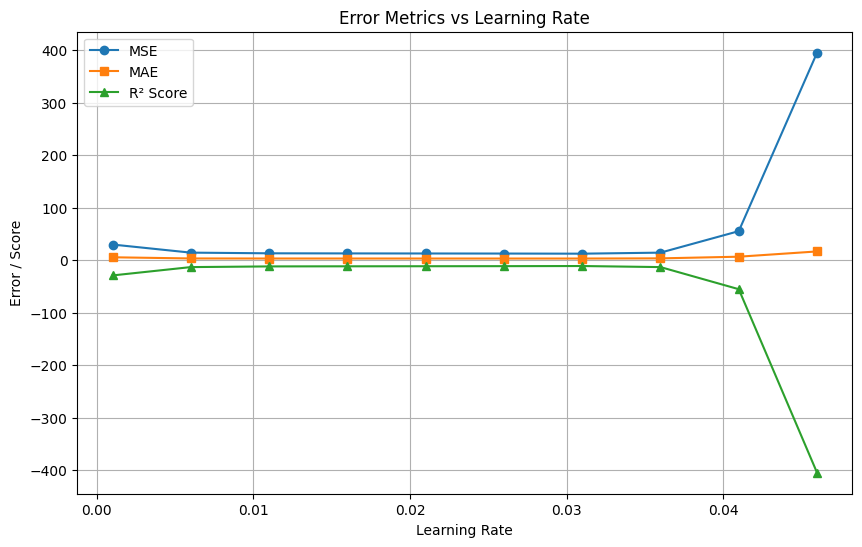

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define learning rates
learning_rates = np.arange(0.001, 0.05, 0.005)

# Store metrics
mse_list = []
mae_list = []
r2_list = []

# Loop through learning rates
for lr in learning_rates:
    model = LinearRegression(lr=lr, iter=5)
    model.fit(X_train.values, y_train.values)

    y_pred = model.predict(X_test.values)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    mse_list.append(mse)
    mae_list.append(mae)
    r2_list.append(r2)

    print(f"LR: {lr:.2f} | MSE: {mse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(learning_rates, mse_list, label='MSE', marker='o')
plt.plot(learning_rates, mae_list, label='MAE', marker='s')
plt.plot(learning_rates, r2_list, label='R² Score', marker='^')
# plt.ylim(min_value, max_value)
plt.xlabel('Learning Rate')
plt.ylabel('Error / Score')
plt.title('Error Metrics vs Learning Rate')
plt.legend()
plt.grid(True)
plt.show()


#Linear Regression using Scikit learn

In [23]:
# Fitting a simple linear regression to Training Set
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()

# fit the regressor on training dataset
regressor.fit(X_train,y_train)

LinearRegression()

In [24]:
# predicting the Test set Results
y_pred = regressor.predict(X_test)
y_pred

array([[5.91836832],
       [7.48633808],
       [5.48144394],
       [6.22204625],
       [6.72094572],
       [7.63197954],
       [7.68465836],
       [6.83250088],
       [6.85419217],
       [4.72224909],
       [7.54211566],
       [6.37698398],
       [4.77492792],
       [6.19105871],
       [6.34599643],
       [5.56201155],
       [5.09719838],
       [5.37298753],
       [5.05691457],
       [7.56690569],
       [6.19415746],
       [5.41017258],
       [7.37478292],
       [5.96484963]])

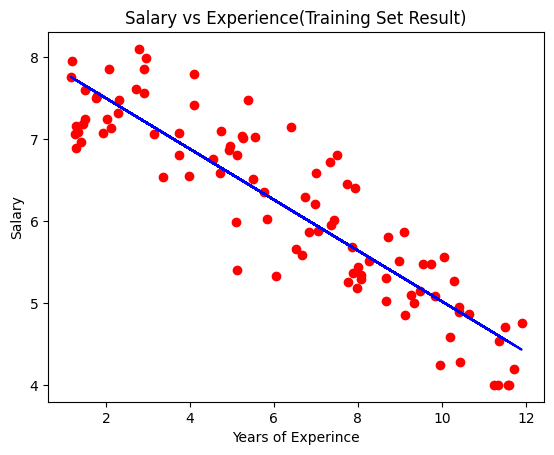

In [25]:
# Visualization the training Set Results

plt.scatter(X_train, y_train, color = 'red')
# this line is for the regressor line
plt.plot(X_train,regressor.predict(X_train), color = 'blue')
plt.title('Salary vs Experience(Training Set Result)')
plt.xlabel('Years of Experince')
plt.ylabel('Salary')
plt.show()


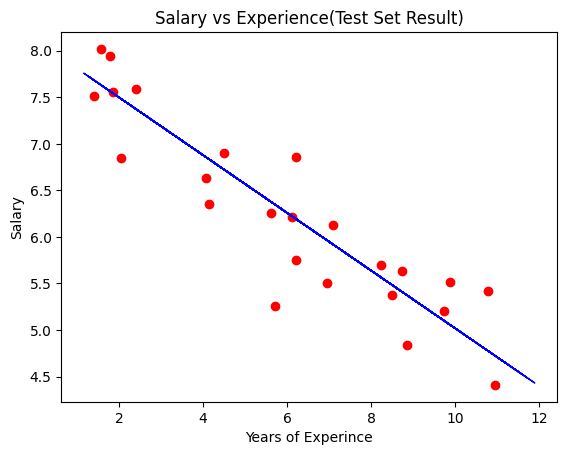

In [26]:
# Visualization the testing Set Results

plt.scatter(X_test, y_test, color = 'red')
plt.plot(X_train,regressor.predict(X_train), color = 'blue',linewidth=1)
plt.title('Salary vs Experience(Test Set Result)')
plt.xlabel('Years of Experince')
plt.ylabel('Salary')
plt.show()


##Evaluation Metrices

1. Mean Absolute Error (MAE)
2. Mean Squared Error (MSE)
3. R-Squared Error

In [27]:
from sklearn.metrics import mean_absolute_error

# MAE
mae_error=mean_absolute_error(y_test,y_pred)
mae_error

0.34212592691723503

In [28]:
from sklearn.metrics import mean_squared_error

# MSE

mse_error=mean_squared_error(y_test,y_pred)
mse_error

0.1785905901895637

In [29]:
from sklearn.metrics import r2_score

# R2_score
r2_score=r2_score(y_test,y_pred)
r2_score

0.816310364105141

#Reference


1.   [SuperDataScience](https://www.superdatascience.com/pages/machine-learning)

2.   [GeeksforGeeks](https://www.geeksforgeeks.org/linear-regression-implementation-from-scratch-using-python/)

